In [46]:
##Bloque 0: Primer intento de creacion de dataset
import json 
import pandas as pd
import os

base_path = 'lars_v1.0.0_annotations'
json_path = os.path.join(base_path, 'train', 'image_annotations.json')#se inspecciona la carpeta train y 
                                                                    #el archivo image_annotations.json de la misma

with open(json_path, 'r') as f:
    data = json.load(f)

print("El tipo de dato principal es:", type(data))
print("Las llaves del diccionario son:", list(data.keys()))



El tipo de dato principal es: <class 'dict'>
Las llaves del diccionario son: ['info', 'licenses', 'annotations']


In [47]:
# Bloque 2: Inspeccionar las llaves de una anotación
# Como se observa en el bloque anterior, se encuentra que una de las llaves del diccionario detectado corresponde a 
#"annotations", que es lo que nos interesa anolizar.

# Accedemos a la lista de anotaciones
lista_de_anotaciones = data['annotations']

# Tomamos solo la primera anotación de la lista
primera_anotacion = lista_de_anotaciones[0]

print("La primera anotación es un:", type(primera_anotacion))
print("Sus llaves son:", list(primera_anotacion.keys()))

La primera anotación es un: <class 'dict'>
Sus llaves son: ['id', 'file_name', 'labels']


In [48]:
# Bloque 3: Ver las llaves dentro de 'labels'
# El interes en "annotations" se deriva del hecho de que el dataset analizado es de segmentación semántica, por tanto en este tipo 
# dataset se añaden labels dependiendo de la clase a la que corresponde cada pixel de la imagen (tal y como puede verse en los 
# resultados del bloque anterior.

# Accedemos al diccionario que está dentro de la llave 'labels'
labels_dict = primera_anotacion['labels']

print("La llave 'labels' contiene un:", type(labels_dict))
print("Y sus llaves internas son:", list(labels_dict.keys()))

La llave 'labels' contiene un: <class 'dict'>
Y sus llaves internas son: ['scene_type', 'lighting', 'reflections', 'waves', 'special']


In [49]:
# Creando dataset
# Bloque 4: Cargar todos los datos y crear el DataFrame inicial
import json
import pandas as pd
import os

base_path = 'lars_v1.0.0_annotations'
all_data = []

print(f"Buscando datos en la carpeta: '{base_path}'...")

for subset in ['train', 'val', 'test']:
    json_path = os.path.join(base_path, subset, 'image_annotations.json')
    
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        # Accedemos a la lista de anotaciones usando la llave 'annotations'
        lista_de_anotaciones = data['annotations']
        
        print(f"  - Archivo '{subset}' cargado. {len(lista_de_anotaciones)} muestras encontradas.")
        
        # Añadimos cada diccionario de la lista a nuestra lista global 'all_data'
        all_data.extend(lista_de_anotaciones)
            
    except FileNotFoundError:
        print(f"  - ERROR: No se encontró el archivo en {json_path}.")

# Creamos el DataFrame inicial
df_inicial = pd.DataFrame(all_data)

print("\nDataFrame inicial creado con éxito.")
print("Dimensiones:", df_inicial.shape)
print("\nPrimeras filas:")
print(df_inicial.head())

Buscando datos en la carpeta: 'lars_v1.0.0_annotations'...
  - Archivo 'train' cargado. 2605 muestras encontradas.
  - Archivo 'val' cargado. 198 muestras encontradas.
  - Archivo 'test' cargado. 1203 muestras encontradas.

DataFrame inicial creado con éxito.
Dimensiones: (4006, 3)

Primeras filas:
   id           file_name                                             labels
0   1  yt010_15_00049.jpg  {'scene_type': 'river_like', 'lighting': 'day_...
1   2  yt010_16_00049.jpg  {'scene_type': 'river_like', 'lighting': 'day_...
2   3  yt010_17_00079.jpg  {'scene_type': 'river_like', 'lighting': 'day_...
3   4  yt010_17_00049.jpg  {'scene_type': 'river_like', 'lighting': 'day_...
4   5  yt010_16_00079.jpg  {'scene_type': 'river_like', 'lighting': 'day_...


In [50]:
# Bloque 5: Procesar la columna 'labels' para crear las características

# La función .apply(pd.Series) es de pandas y sirve para expandir una columna de diccionarios
df_labels_expandido = df_inicial['labels'].apply(pd.Series)

# Unimos este nuevo DataFrame con las columnas que nos interesan del original (como 'file_name')
df_final = pd.concat([df_inicial['file_name'], df_labels_expandido], axis=1)

# Finalmente se tiene un DataFrame que está listo para ser usado
print("DataFrame final listo para el modelado:")
print(df_final.head())

print("\nColumnas disponibles:", list(df_final.columns))

DataFrame final listo para el modelado:
            file_name  scene_type  lighting reflections  waves  \
0  yt010_15_00049.jpg  river_like  day_like    moderate  still   
1  yt010_16_00049.jpg  river_like  day_like       heavy  still   
2  yt010_17_00079.jpg  river_like  day_like       heavy  still   
3  yt010_17_00049.jpg  river_like  day_like       heavy  still   
4  yt010_16_00079.jpg  river_like  day_like       heavy  still   

                                             special  
0  {'extra_dark': False, 'extra_bright': False, '...  
1  {'extra_dark': False, 'extra_bright': False, '...  
2  {'extra_dark': False, 'extra_bright': False, '...  
3  {'extra_dark': False, 'extra_bright': False, '...  
4  {'extra_dark': False, 'extra_bright': False, '...  

Columnas disponibles: ['file_name', 'scene_type', 'lighting', 'reflections', 'waves', 'special']


In [51]:
# Bloque 6: Construir el DataFrame final y limpio

base_path = 'lars_v1.0.0_annotations'
all_data_rows = []

print("Procesando archivos para crear el DataFrame final...")

for subset in ['train', 'val', 'test']:
    json_path = os.path.join(base_path, subset, 'image_annotations.json')
    
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        lista_de_anotaciones = data['annotations']
        print(f"  - Procesando {len(lista_de_anotaciones)} muestras de '{subset}'...")
        
        for annotation in lista_de_anotaciones:
            # Accedemos al diccionario de etiquetas
            labels_dict = annotation['labels']
            
            # Creamos una fila con los datos que nos interesan
            row = {
                'scene_type': labels_dict.get('scene_type'),
                'lighting': labels_dict.get('lighting'),
                'reflections': labels_dict.get('reflections'),
                'waves': labels_dict.get('waves'),
                'special': labels_dict.get('special')
            }
            all_data_rows.append(row)
            
    except FileNotFoundError:
        print(f"  - ERROR: No se encontró el archivo en {json_path}.")

# Se procede a crear el DataFrame final a partir de la lista de filas
df = pd.DataFrame(all_data_rows)

print("\nDataFrame final")
print("Dimensiones:", df.shape)
print("\nPrimeras 5 filas:")
print(df.head())

Procesando archivos para crear el DataFrame final...
  - Procesando 2605 muestras de 'train'...
  - Procesando 198 muestras de 'val'...
  - Procesando 1203 muestras de 'test'...

DataFrame final
Dimensiones: (4006, 5)

Primeras 5 filas:
   scene_type  lighting reflections  waves  \
0  river_like  day_like    moderate  still   
1  river_like  day_like       heavy  still   
2  river_like  day_like       heavy  still   
3  river_like  day_like       heavy  still   
4  river_like  day_like       heavy  still   

                                             special  
0  {'extra_dark': False, 'extra_bright': False, '...  
1  {'extra_dark': False, 'extra_bright': False, '...  
2  {'extra_dark': False, 'extra_bright': False, '...  
3  {'extra_dark': False, 'extra_bright': False, '...  
4  {'extra_dark': False, 'extra_bright': False, '...  


In [52]:
#BLoque 9
#se proceso a revisar los keys de la columna "special"
i=0
for diccionario in df['special']:
    i=i+1
    print("Claves:", diccionario.keys())
    print("Valores:", diccionario.values())
    print("-" * 20)
    if(i>0):
        break

Claves: dict_keys(['extra_dark', 'extra_bright', 'glitter', 'dirty_lens', 'wakes', 'rain', 'fog', 'plants_debris'])
Valores: dict_values([False, False, False, False, False, False, False, False])
--------------------


In [53]:
#BLoque 10
# --- Paso 1: Aplanar la columna 'special' --- el objetivo es tener el mismo tipo de dato en las columnas del dataframe

# Carga de la columna 'special' como un DataFrame separado
df_special_expandido = df_final['special'].apply(pd.Series)

# Conversión de los valores Booleanos (True/False) a enteros (1/0)
df_special_numerico = df_special_expandido.astype(int)

# Se añade un prefijo para que sepamos de dónde vienen estas columnas
df_special_numerico = df_special_numerico.add_prefix('special_')

# Se lleva a cabo la unión de estas nuevas columnas al resto de las características
# Se elimina la columna original 'special'
X_con_special = pd.concat([df_final.drop(columns=['special']), df_special_numerico], axis=1)

# Finalmente se quita el file_name y la variable objetivo para tener el set de características completo
X_completo = X_con_special.drop(columns=['scene_type', 'file_name'])

print("Nuevas características creadas desde la columna 'special':")
#print(f"  - Columna '{columna}': contiene un {type(primer_valor)}")
print(f"EL tamanio de X_completo es {X_completo.shape}")
print(X_completo.head(20))

Nuevas características creadas desde la columna 'special':
EL tamanio de X_completo es (4006, 11)
     lighting reflections     waves  special_extra_dark  special_extra_bright  \
0    day_like    moderate     still                   0                     0   
1    day_like       heavy     still                   0                     0   
2    day_like       heavy     still                   0                     0   
3    day_like       heavy     still                   0                     0   
4    day_like       heavy     still                   0                     0   
5    day_like    moderate  moderate                   0                     0   
6    day_like    moderate  moderate                   0                     0   
7   dusk_like        none  moderate                   1                     0   
8    day_like    moderate  moderate                   0                     0   
9    day_like    moderate  moderate                   0                     0   
10   day_li

In [54]:
#BLoque 11
#modelo simplificado..

print("Características originales en X_completo:")
print(list(X_completo.columns))

# Definimos las columnas que, según el análisis, no aportan valor
columnas_a_eliminar = ['lighting'] 

# Creamos el nuevo DataFrame sin esas columnas
X_simplificado = X_completo.drop(columns=columnas_a_eliminar)

print("\nCaracterísticas en X_simplificado (después de eliminar 'lighting'):")
print(list(X_simplificado.columns))

Características originales en X_completo:
['lighting', 'reflections', 'waves', 'special_extra_dark', 'special_extra_bright', 'special_glitter', 'special_dirty_lens', 'special_wakes', 'special_rain', 'special_fog', 'special_plants_debris']

Características en X_simplificado (después de eliminar 'lighting'):
['reflections', 'waves', 'special_extra_dark', 'special_extra_bright', 'special_glitter', 'special_dirty_lens', 'special_wakes', 'special_rain', 'special_fog', 'special_plants_debris']


In [55]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

X = X_simplificado

# --- PASO 1: Primero, convertir todo a formato numérico ---
X_numerico = pd.get_dummies(X)

# --- PASO 2: Escalar los datos que ya son numéricos ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numerico)

print("¡Datos listos y escalados correctamente!")
print("Forma de los datos escalados:", X_scaled.shape)

¡Datos listos y escalados correctamente!
Forma de los datos escalados: (4006, 14)


In [56]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import KMeans
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.cluster import Birch

In [57]:
#KMEANS


Calculating inertia for different values of K...
Calculation complete. Generating plot...


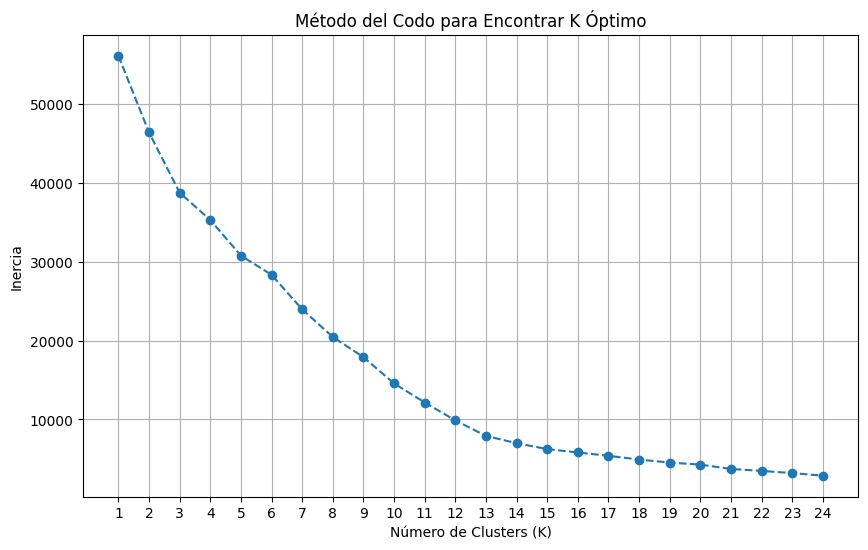

In [58]:
# --- Elbow Method ---
inertia = []
K_range = range(1, 25)
print("\nCalculating inertia for different values of K...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

print("Calculation complete. Generating plot...")

# --- Step 3: Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Método del Codo para Encontrar K Óptimo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [59]:
#del grafico se deduce que el numero optimo de clusteres es de 2

In [75]:
km = KMeans(n_clusters=3)
km.fit(X_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [76]:
km.cluster_centers_

array([[ 1.71641931e-03, -7.82820707e-03,  2.11855867e-02,
        -1.33358737e-01,  2.27955363e-02, -2.87076078e-02,
        -3.31972900e-02, -6.77375469e-02, -1.72791247e-01,
        -1.01052124e-03,  6.84370359e-02,  2.80404181e-01,
         5.04511731e-03, -2.86051651e-01],
       [-6.85602417e-02,  3.16832244e-02, -1.49714542e-01,
         7.49857129e+00, -7.24456521e-02,  1.05848500e+00,
         9.76043932e-02,  1.04195793e-01,  1.71569542e-01,
         2.17084576e-01, -2.81487993e-01, -2.37338216e-01,
        -5.00250188e-02,  2.54223178e-01],
       [-4.87149137e-03,  8.84478781e-02, -2.24290680e-01,
        -1.33358737e-01, -2.62228152e-01,  1.02266111e-01,
         3.83746232e-01,  8.05398072e-01,  2.07669186e+00,
        -3.87832780e-02, -7.72182539e-01, -3.37972100e+00,
        -5.00250188e-02,  3.44493715e+00]])

In [77]:
km.labels_

array([2, 2, 2, ..., 0, 0, 0], shape=(4006,), dtype=int32)

In [78]:
km.inertia_ #Sum of squared distances of samples to their closest cluster center

42585.63355942555

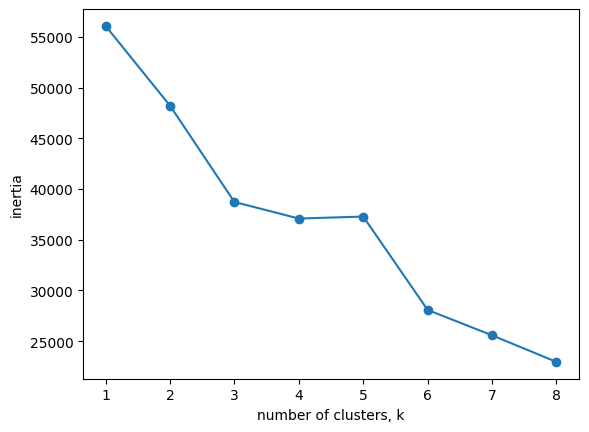

In [80]:
ks = range(1, 9)
inertias = []
for k in ks:
    # Create a KMeans instance with k clusters: model
    model_prueba = KMeans(n_clusters=k)
    
    # Fit model to samples
    model_prueba.fit(X_scaled)
    
    # Append the inertia to the list of inertias
    inertias.append(model_prueba.inertia_)
    
# Plot ks vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

In [81]:
#Silhouette 
#Values close to 1: Indicate that the sample is well-clustered, meaning it is far away from other clusters and close to samples within its own cluster.
#Values close to 0: Suggest that the sample is on or very close to the decision boundary between two clusters, indicating potential overlap.
#Values close to -1: Imply that the sample might be assigned to the wrong cluster.
#SCORE da el promedio de todos los valores.
score = silhouette_score(X_scaled, km.labels_)
score

0.5503410355444426

In [82]:
#el numero 0.3554 nos indica que el numero de clusteres seleccionado nos da dos grupos que no estan complemetamente diferenciados, posiblemente hay
#una frontera difusa entre ambos grupos, un ligero overlap.

In [83]:
samples = silhouette_samples(X_scaled, km.labels_)
samples

array([0.28442531, 0.41933674, 0.41933674, ..., 0.66407631, 0.64396043,
       0.66407631], shape=(4006,))

In [84]:
#PCA

In [85]:
pca = PCA(n_components=2)

In [86]:
pca.fit(X_scaled)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [87]:
pca.components_

array([[ 0.05463189,  0.00876736, -0.09833328,  0.04275214, -0.10765142,
         0.02860389,  0.05062318,  0.22984721,  0.43529993,  0.1424081 ,
        -0.31123489, -0.55158039,  0.03353356,  0.55285005],
       [ 0.20643818,  0.0036842 , -0.11433713,  0.02620423, -0.15010155,
         0.01449918, -0.13464221,  0.02824023, -0.21554956,  0.66028657,
        -0.576252  ,  0.20416151, -0.10386986, -0.1869923 ]])

In [88]:
pca.explained_variance_ratio_

array([0.19201549, 0.14299397])

In [89]:
pca.explained_variance_ratio_.cumsum()

array([0.19201549, 0.33500946])

In [90]:
X_scaled_reduced = pca.transform(X_scaled)

In [91]:
X_scaled_reduced[0:3]

array([[ 4.1519317 , -0.04030532],
       [ 6.13092338, -2.48336985],
       [ 6.13092338, -2.48336985]])

In [97]:
X_scaled[0:3]

array([[-0.42545758, -0.10538265, -0.26507451, -0.13335874, -0.28758078,
        -0.07599041, -0.28349034, -0.1640615 , -0.19994807,  1.04651244,
        -0.96757484, -3.41719405, -0.05002502,  3.49587215],
       [-0.42545758, -0.10538265, -0.26507451, -0.13335874, -0.28758078,
        -0.07599041, -0.28349034, -0.1640615 ,  5.00129853, -0.95555482,
        -0.96757484, -3.41719405, -0.05002502,  3.49587215],
       [-0.42545758, -0.10538265, -0.26507451, -0.13335874, -0.28758078,
        -0.07599041, -0.28349034, -0.1640615 ,  5.00129853, -0.95555482,
        -0.96757484, -3.41719405, -0.05002502,  3.49587215]])

In [98]:
#KMEANS CON PCA
km_pca = KMeans(n_clusters=3)
km_pca.fit(X_scaled_reduced)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [99]:
#Silhouette 
#Values close to 1: Indicate that the sample is well-clustered, meaning it is far away from other clusters and close to samples within its own cluster.
#Values close to 0: Suggest that the sample is on or very close to the decision boundary between two clusters, indicating potential overlap.
#Values close to -1: Imply that the sample might be assigned to the wrong cluster.
#SCORE da el promedio de todos los valores.
score = silhouette_score(X_scaled_reduced, km_pca.labels_)
score

0.8335552597696597

In [100]:
#Visualizacion

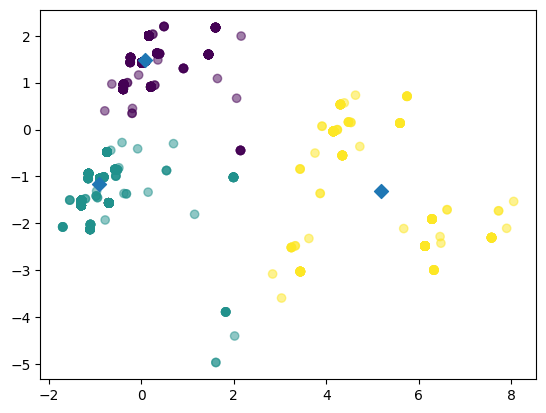

In [101]:
centroids = km_pca.cluster_centers_
centroids_x = centroids[:,0]
centroids_y = centroids[:,1]

xs = X_scaled_reduced[:,0]
ys = X_scaled_reduced[:,1]

plt.scatter(xs, ys, c=km_pca.labels_, alpha=0.5)

plt.scatter(centroids_x, centroids_y, marker='D', s=50)

plt.show()

In [102]:
#MEAN SHIFT 

In [133]:
bandwidth = estimate_bandwidth(X_scaled_reduced, quantile=0.4)

In [134]:
ms = MeanShift(bandwidth=bandwidth)
ms.fit(X_scaled_reduced)

,bandwidth,np.float64(1.1360349914202479)
,seeds,None
,bin_seeding,False
,min_bin_freq,1
,cluster_all,True
,n_jobs,None
,max_iter,300


In [135]:
cantidad_de_clusters = len(np.unique(ms.labels_))
cantidad_de_clusters

8

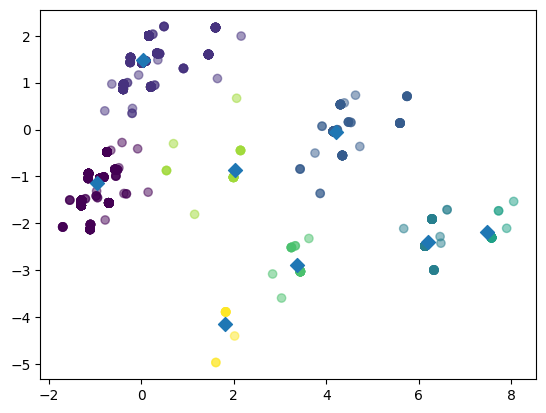

In [136]:
centroids = ms.cluster_centers_
centroids_x = centroids[:,0]
centroids_y = centroids[:,1]

xs = X_scaled_reduced[:,0]
ys = X_scaled_reduced[:,1]

plt.scatter(xs, ys, c=ms.labels_, alpha=0.5)

plt.scatter(centroids_x, centroids_y, marker='D', s=50)

plt.show()

In [137]:
#Silhouette 
#Values close to 1: Indicate that the sample is well-clustered, meaning it is far away from other clusters and close to samples within its own cluster.
#Values close to 0: Suggest that the sample is on or very close to the decision boundary between two clusters, indicating potential overlap.
#Values close to -1: Imply that the sample might be assigned to the wrong cluster.
#SCORE da el promedio de todos los valores.
score = silhouette_score(X_scaled_reduced, ms.labels_)
score

0.853492612143021

In [138]:
#DBSCAN

In [139]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan.fit(X_scaled_reduced)

,eps,0.5
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [140]:
cantidad_de_clusters = len(np.unique(dbscan.labels_))
cantidad_de_clusters

19

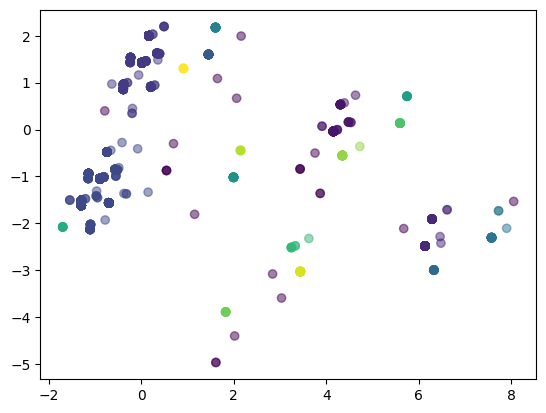

In [142]:
xs = X_scaled_reduced[:,0]
ys = X_scaled_reduced[:,1]

plt.scatter(xs, ys, c=dbscan.labels_, alpha=0.5)

plt.show()

In [143]:
#Silhouette 
#Values close to 1: Indicate that the sample is well-clustered, meaning it is far away from other clusters and close to samples within its own cluster.
#Values close to 0: Suggest that the sample is on or very close to the decision boundary between two clusters, indicating potential overlap.
#Values close to -1: Imply that the sample might be assigned to the wrong cluster.
#SCORE da el promedio de todos los valores.
score = silhouette_score(X_scaled_reduced, dbscan.labels_)
score

0.6641105174757621

In [144]:
#Gaussian Mixture

In [145]:
gmm = GaussianMixture(n_components=3)
gmm.fit(X_scaled_reduced)

,n_components,3
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,None


In [146]:
labels_gmm = gmm.predict(X_scaled_reduced)

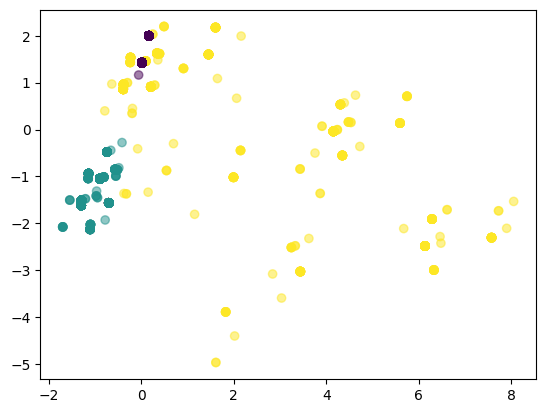

In [147]:
xs = X_scaled_reduced[:,0]
ys = X_scaled_reduced[:,1]

plt.scatter(xs, ys, c=labels_gmm, alpha=0.5)

plt.show()

In [148]:
#Silhouette 
#Values close to 1: Indicate that the sample is well-clustered, meaning it is far away from other clusters and close to samples within its own cluster.
#Values close to 0: Suggest that the sample is on or very close to the decision boundary between two clusters, indicating potential overlap.
#Values close to -1: Imply that the sample might be assigned to the wrong cluster.
#SCORE da el promedio de todos los valores.
score = silhouette_score(X_scaled_reduced, labels_gmm)
score

0.7125761342571381

In [149]:
#BIRCH

In [158]:
birch = Birch(threshold=0.5, branching_factor=50, n_clusters=None)
birch.fit(X_scaled_reduced)

,threshold,0.5
,branching_factor,50
,n_clusters,None
,compute_labels,True
,copy,'deprecated'


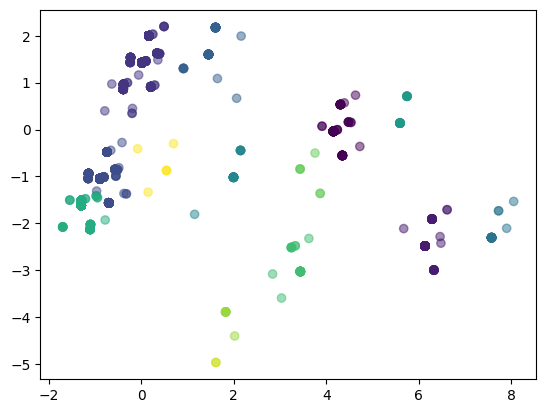

In [159]:
xs = X_scaled_reduced[:,0]
ys = X_scaled_reduced[:,1]

plt.scatter(xs, ys, c=birch.labels_, alpha=0.5)

plt.show()

In [160]:
#Silhouette 
#Values close to 1: Indicate that the sample is well-clustered, meaning it is far away from other clusters and close to samples within its own cluster.
#Values close to 0: Suggest that the sample is on or very close to the decision boundary between two clusters, indicating potential overlap.
#Values close to -1: Imply that the sample might be assigned to the wrong cluster.
#SCORE da el promedio de todos los valores.
score = silhouette_score(X_scaled_reduced, birch.labels_)
score

0.7714185949832685

In [161]:
#OTROS DATASETS